In [120]:
pip install pandas numpy matplotlib seaborn jupyter openpyxl

Note: you may need to restart the kernel to use updated packages.


In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [122]:
df = pd.read_csv("../Customer_Churn_Analysis/Telco_Customer_Churn_Dataset .csv")

In [123]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [124]:
df.shape

(7043, 21)

In [125]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [126]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [128]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [129]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [130]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [131]:
df["TotalCharges"].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
Name: count, dtype: int64

In [132]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [133]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [134]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [135]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [136]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [137]:
df = df.dropna(subset=["TotalCharges"])

In [138]:
df.shape

(7032, 21)

In [139]:
df.duplicated().sum()

np.int64(0)

In [140]:
df["customerID"].duplicated().sum()

np.int64(0)

In [141]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique()[:10])


 customerID
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU']
Length: 10, dtype: str

 gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

 SeniorCitizen
[0 1]

 Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 tenure
[ 1 34  2 45  8 22 10 28 62 13]

 PhoneService
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

 MultipleLines
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

 InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

 OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

 DeviceProtection
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

 TechSupport
<StringArray>
['No', 'Yes', 'No internet

In [142]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [143]:
df["ChurnFlag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [144]:
df[["Churn", "ChurnFlag"]].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [145]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns.drop("Churn"),
    drop_first=True,
    dtype=int
)

In [146]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,ChurnFlag,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,No,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,No,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,Yes,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,No,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,Yes,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [147]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Columns: 7063 entries, SeniorCitizen to PaymentMethod_Mailed check
dtypes: float64(2), int64(7060), str(1)
memory usage: 379.0 MB


In [148]:
df_encoded.isnull().sum().sum()

np.int64(0)

In [149]:
df.to_csv(
    "../Customer_Churn_Analysis/outputs/cleaned_data/telco_cleaned.csv",
    index=False
)

In [150]:
df_encoded.to_csv(
    "../Customer_Churn_Analysis/outputs/cleaned_data/telco_encoded.csv",
    index=False
)

In [151]:
churn_counts = df["Churn"].value_counts()

churn_counts

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [152]:
churn_rate = (
    df["Churn"].value_counts(normalize=True)["Yes"] * 100
)

print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.58%


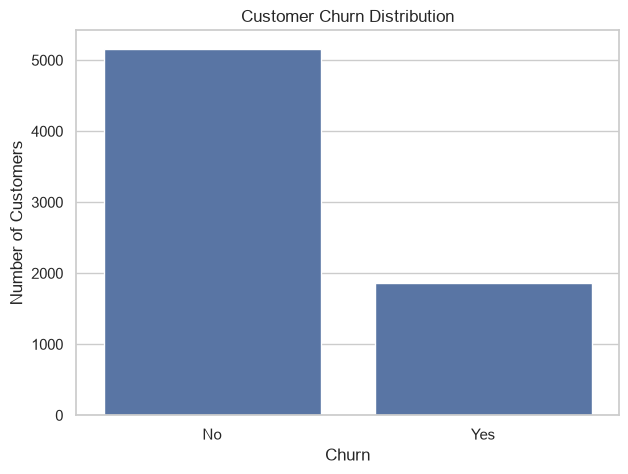

In [153]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [154]:
plt.savefig(
    "../Customer_Churn_Analysis/outputs/charts/01_churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [155]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


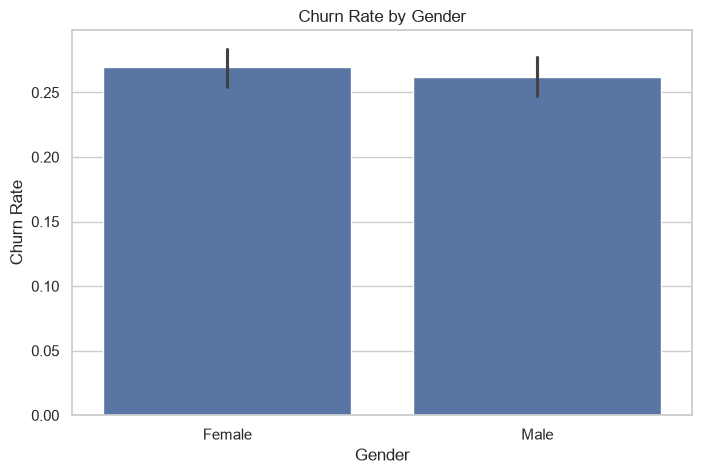

In [156]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="gender",
    y="ChurnFlag"
)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.xlabel("Gender")

plt.show()

In [157]:
senior_churn = (
    df.groupby("SeniorCitizen")["ChurnFlag"]
    .mean()
    .mul(100)
)

senior_churn

SeniorCitizen
0    23.650255
1    41.681261
Name: ChurnFlag, dtype: float64

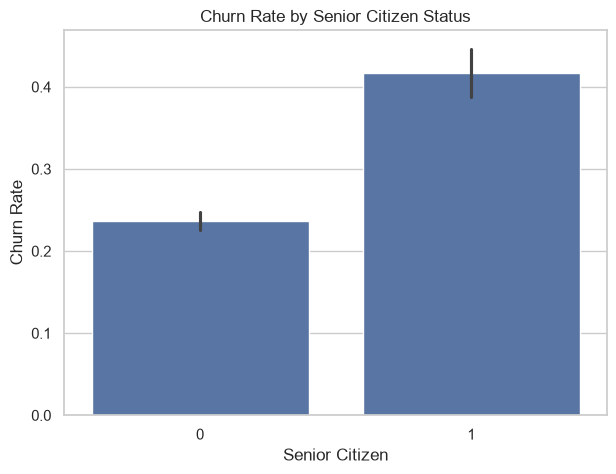

In [158]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="SeniorCitizen",
    y="ChurnFlag"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate")

plt.show()

In [159]:
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: ChurnFlag, dtype: float64

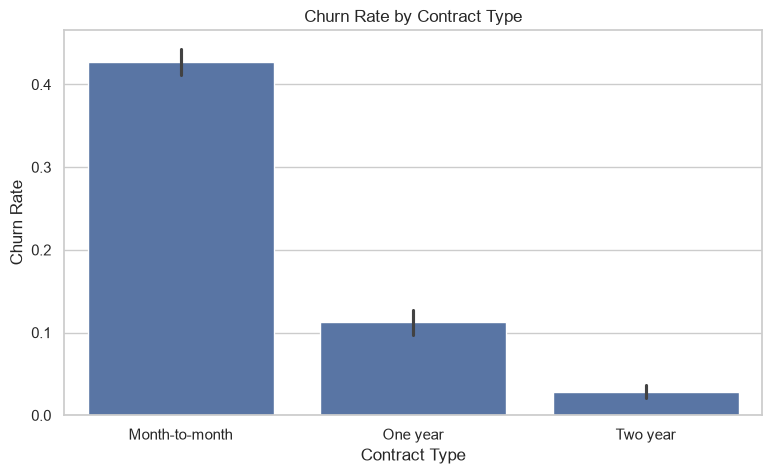

In [160]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Contract",
    y="ChurnFlag"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

In [161]:
payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: ChurnFlag, dtype: float64

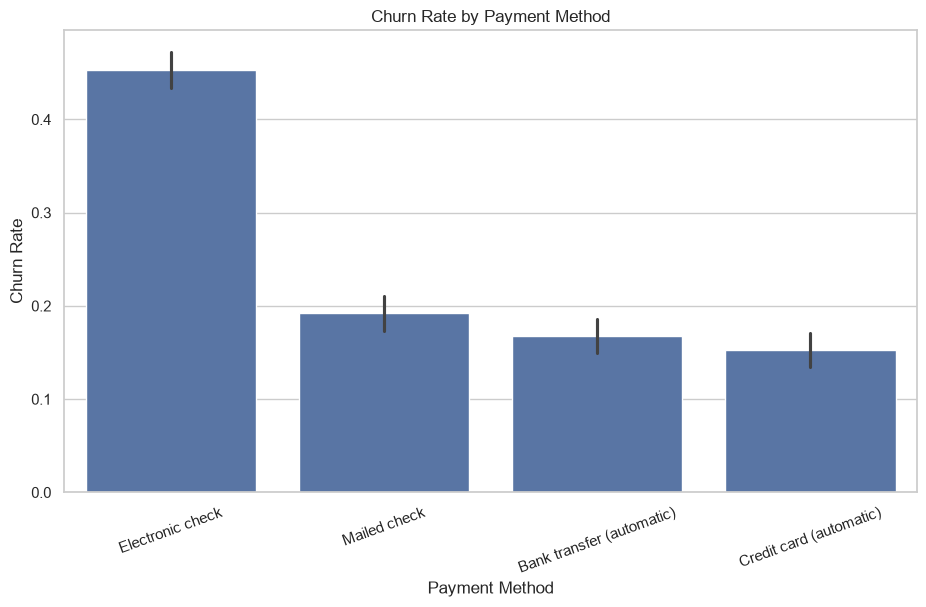

In [162]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=df,
    x="PaymentMethod",
    y="ChurnFlag"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")

plt.xticks(rotation=20)

plt.show()

In [163]:
internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

internet_churn

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: ChurnFlag, dtype: float64

In [164]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

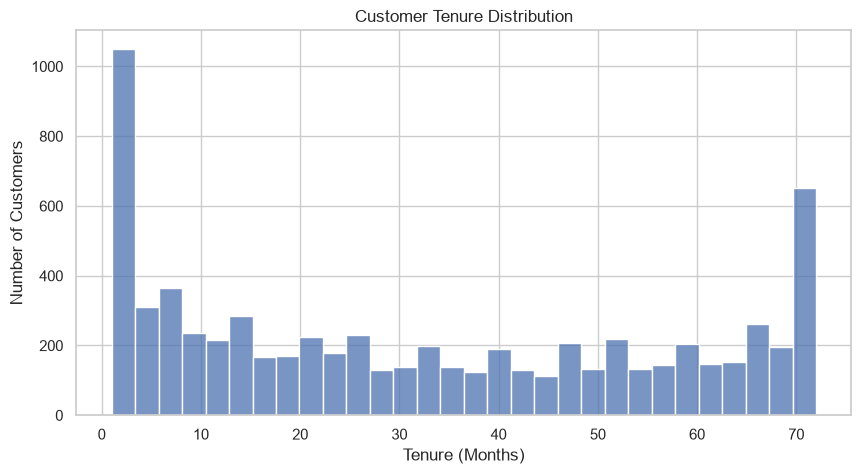

In [165]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [166]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [167]:
df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-6 Months      1470
7-12 Months      705
13-24 Months    1024
25-48 Months    1594
49-72 Months    2239
Name: count, dtype: int64

In [168]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["ChurnFlag"]
    .mean()
    .mul(100)
)

tenure_churn

TenureGroup
0-6 Months      53.333333
7-12 Months     35.886525
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: ChurnFlag, dtype: float64

In [169]:
tenure_segment = (
    df.groupby("TenureGroup", observed=True)
    .agg(
        Customers=("customerID", "count"),
        ChurnRate=("ChurnFlag", "mean")
    )
)

tenure_segment["ChurnRate"] *= 100

tenure_segment

,Customers,ChurnRate
TenureGroup,,
0-6 Months,1470,53.333333
7-12 Months,705,35.886525
13-24 Months,1024,28.710938
25-48 Months,1594,20.388959
49-72 Months,2239,9.513176


In [170]:
df["MonthlyChargeSegment"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [171]:
df["MonthlyChargeSegment"].value_counts()

MonthlyChargeSegment
High         2679
Low          1832
Medium       1619
Very High     902
Name: count, dtype: int64

In [172]:
charge_segment = (
    df.groupby("MonthlyChargeSegment", observed=True)
    .agg(
        Customers=("customerID", "count"),
        ChurnRate=("ChurnFlag", "mean"),
        AvgMonthlyCharge=("MonthlyCharges", "mean")
    )
)

charge_segment["ChurnRate"] *= 100

charge_segment

,Customers,ChurnRate,AvgMonthlyCharge
MonthlyChargeSegment,,,
Low,1832,11.681223,22.878794
Medium,1619,23.965411,55.959821
High,2679,37.849944,84.708996
Very High,902,28.048780,106.665965


In [173]:
charge_segment = (
    df.groupby("MonthlyChargeSegment", observed=True)
    .agg(
        Customers=("customerID", "count"),
        ChurnRate=("ChurnFlag", "mean"),
        AvgMonthlyCharge=("MonthlyCharges", "mean")
    )
)

charge_segment["ChurnRate"] *= 100

charge_segment

,Customers,ChurnRate,AvgMonthlyCharge
MonthlyChargeSegment,,,
Low,1832,11.681223,22.878794
Medium,1619,23.965411,55.959821
High,2679,37.849944,84.708996
Very High,902,28.048780,106.665965


In [175]:
contract_segment = (
    df.groupby("Contract")
    .agg(
        Customers=("customerID", "count"),
        AvgMonthlyCharges=("MonthlyCharges", "mean"),
        AvgTenure=("tenure", "mean"),
        ChurnRate=("ChurnFlag", "mean")
    )
)

contract_segment["ChurnRate"] *= 100

contract_segment

,Customers,AvgMonthlyCharges,AvgTenure,ChurnRate
Contract,,,,
Month-to-month,3875,66.398490,18.036645,42.709677
One year,1472,65.079416,42.073370,11.277174
Two year,1685,60.872374,57.071810,2.848665


In [177]:
df["CustomerSegment"] = (
    df["TenureGroup"].astype(str)
    + " | "
    + df["MonthlyChargeSegment"].astype(str)
    + " | "
    + df["Contract"].astype(str)
)

In [178]:
df["CustomerSegment"].value_counts().head(20)

CustomerSegment
0-6 Months | High | Month-to-month        536
0-6 Months | Medium | Month-to-month      446
25-48 Months | High | Month-to-month      411
0-6 Months | Low | Month-to-month         409
49-72 Months | High | Two year            401
13-24 Months | High | Month-to-month      378
49-72 Months | Low | Two year             378
49-72 Months | Very High | Two year       285
7-12 Months | High | Month-to-month       270
49-72 Months | High | One year            226
49-72 Months | Very High | One year       207
49-72 Months | Medium | Two year          199
13-24 Months | Medium | Month-to-month    184
49-72 Months | High | Month-to-month      178
25-48 Months | Medium | Month-to-month    172
25-48 Months | High | One year            171
25-48 Months | Low | Two year             165
7-12 Months | Medium | Month-to-month     158
25-48 Months | Low | One year             149
25-48 Months | Medium | One year          139
Name: count, dtype: int64

In [179]:
segment_analysis = (
    df.groupby("CustomerSegment")
    .agg(
        Customers=("customerID", "count"),
        AvgMonthlyCharges=("MonthlyCharges", "mean"),
        AvgTenure=("tenure", "mean"),
        ChurnRate=("ChurnFlag", "mean")
    )
)

segment_analysis["ChurnRate"] *= 100

segment_analysis = segment_analysis.sort_values(
    "ChurnRate",
    ascending=False
)

segment_analysis.head(15)

,Customers,AvgMonthlyCharges,AvgTenure,ChurnRate
CustomerSegment,,,,
0-6 Months | Very High | One year,1,105.650000,4.000000,100.000000
0-6 Months | Very High | Month-to-month,22,103.327273,3.272727,77.272727
7-12 Months | Very High | Month-to-month,28,103.050000,9.571429,75.000000
0-6 Months | High | Month-to-month,536,81.054011,2.682836,72.574627
7-12 Months | High | Month-to-month,270,83.396667,9.311111,60.740741
13-24 Months | Very High | Month-to-month,52,103.613462,18.576923,59.615385
0-6 Months | Medium | Month-to-month,446,53.771076,2.428251,52.466368
13-24 Months | High | Month-to-month,378,85.446296,18.082011,47.619048
25-48 Months | Very High | Month-to-month,128,104.535547,37.109375,46.875000


In [180]:
segment_analysis[
    segment_analysis["Customers"] >= 50
].head(15)

,Customers,AvgMonthlyCharges,AvgTenure,ChurnRate
CustomerSegment,,,,
0-6 Months | High | Month-to-month,536,81.054011,2.682836,72.574627
7-12 Months | High | Month-to-month,270,83.396667,9.311111,60.740741
13-24 Months | Very High | Month-to-month,52,103.613462,18.576923,59.615385
0-6 Months | Medium | Month-to-month,446,53.771076,2.428251,52.466368
13-24 Months | High | Month-to-month,378,85.446296,18.082011,47.619048
25-48 Months | Very High | Month-to-month,128,104.535547,37.109375,46.875000
25-48 Months | High | Month-to-month,411,86.617640,34.523114,40.145985
49-72 Months | Very High | Month-to-month,94,105.402128,59.638298,35.106383
0-6 Months | Low | Month-to-month,409,22.626773,2.234719,34.229829


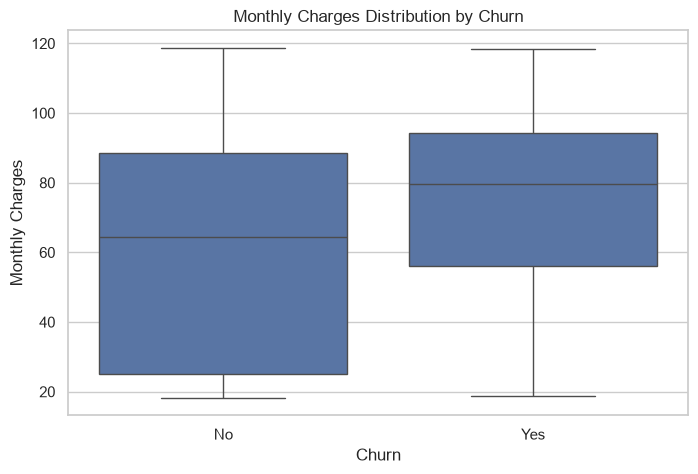

In [181]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

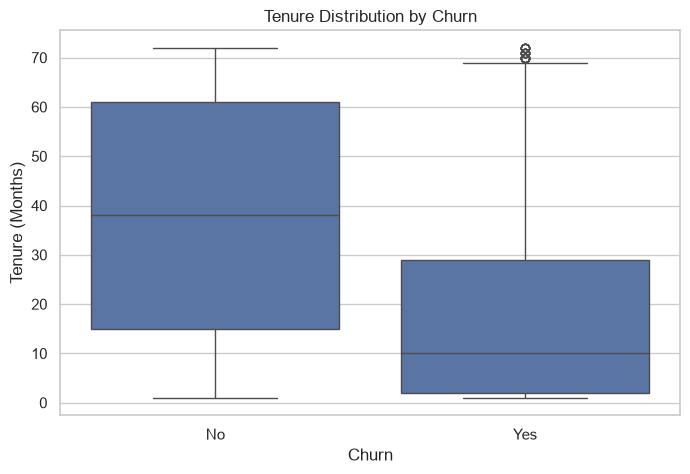

In [182]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

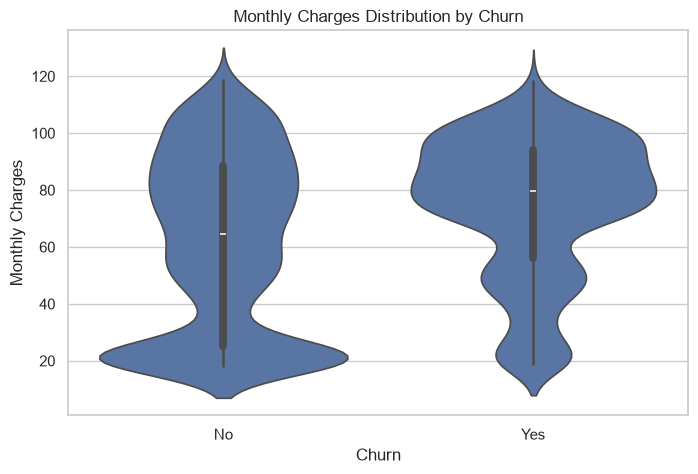

In [183]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

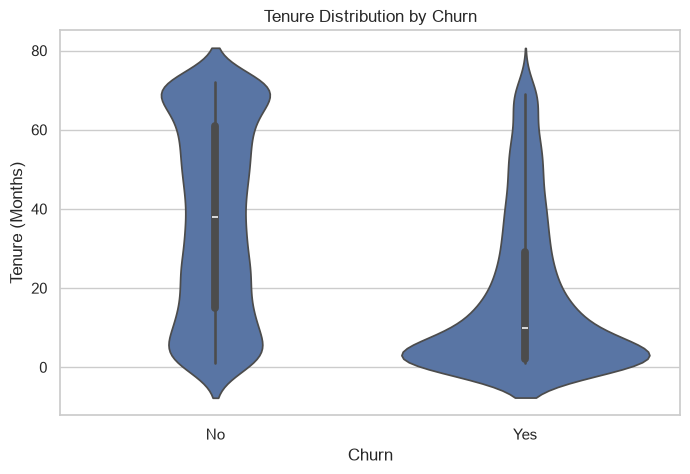

In [184]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [185]:
pair_data = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"
    ]
]

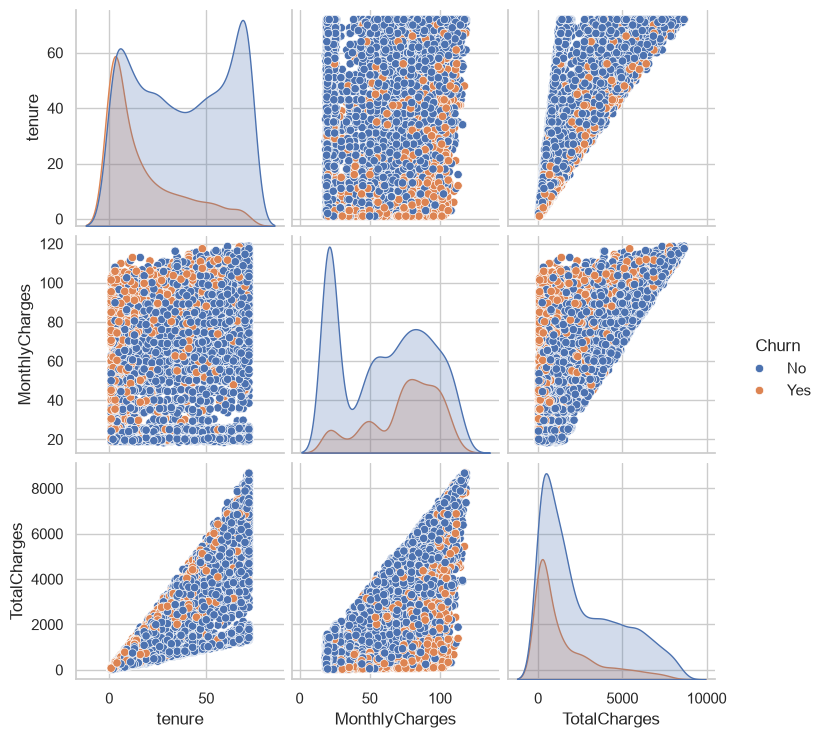

In [186]:
sns.pairplot(
    pair_data,
    hue="Churn"
)

plt.show()

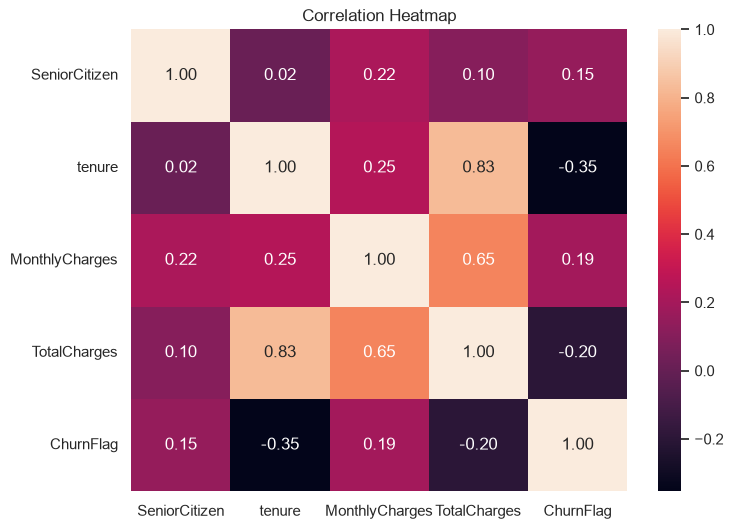

In [187]:
numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnFlag"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

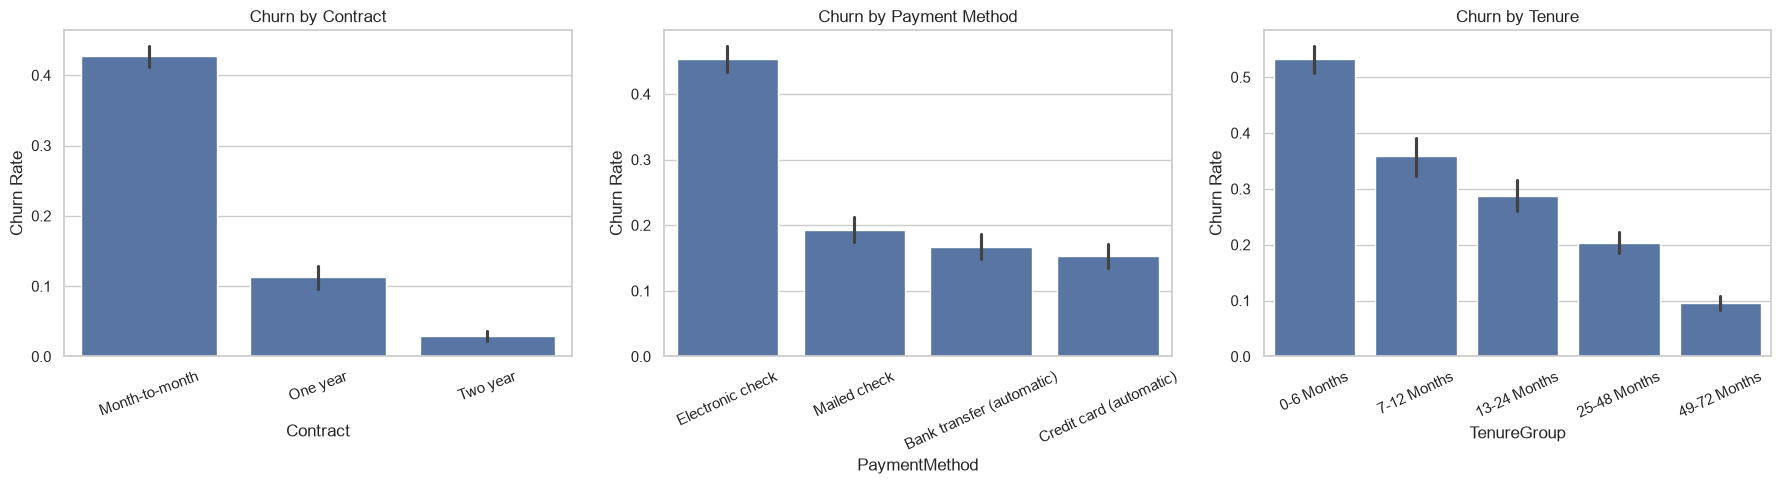

In [188]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=df,
    x="Contract",
    y="ChurnFlag",
    ax=axes[0]
)

axes[0].set_title("Churn by Contract")
axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis="x", rotation=20)


sns.barplot(
    data=df,
    x="PaymentMethod",
    y="ChurnFlag",
    ax=axes[1]
)

axes[1].set_title("Churn by Payment Method")
axes[1].set_ylabel("Churn Rate")
axes[1].tick_params(axis="x", rotation=25)


sns.barplot(
    data=df,
    x="TenureGroup",
    y="ChurnFlag",
    ax=axes[2]
)

axes[2].set_title("Churn by Tenure")
axes[2].set_ylabel("Churn Rate")
axes[2].tick_params(axis="x", rotation=25)


plt.tight_layout()
plt.show()

In [189]:
plt.savefig(
    "../Customer_Churn_Analysis/outputs/charts/churn_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [190]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Overall Churn Rate",
        "Average Tenure",
        "Average Monthly Charges",
        "Average Total Charges"
    ],
    "Value": [
        len(df),
        (df["Churn"] == "Yes").sum(),
        f"{df['ChurnFlag'].mean() * 100:.2f}%",
        f"{df['tenure'].mean():.2f} months",
        f"{df['MonthlyCharges'].mean():.2f}",
        f"{df['TotalCharges'].mean():.2f}"
    ]
})

summary

,Metric,Value
0,Total Customers,7032
1,Churned Customers,1869
2,Overall Churn Rate,26.58%
3,Average Tenure,32.42 months
4,Average Monthly Charges,64.80
5,Average Total Charges,2283.30
